# Ball and Beam Simulation

Simulating a tiltiing beam balancing a ball at the middle position.

Importing packages

In [1]:
try: 
    from jax import config
    config.update("jax_enable_x64", True)
    import time
    import math
    import jax
    import jax.numpy as jnp
    from meshcat import Visualizer
    import meshcat.geometry as mc_geom
    import meshcat.transformations as mc_trans
    from pydrake.all import LinearQuadraticRegulator
    from flax import nnx
    import optax
    from tqdm import tqdm
    %matplotlib ipympl
    import matplotlib.pyplot as plt
    
    # local imports
    from pid import PIDController
    from rk4 import rk4_step
    from custom_plots import BallPlot
    from control_utilities import check_controllability

    print('Imported packages.')
except Exception as e:
    print('Importing packages failed:')
    print(e)
    raise e

Imported packages.


Initialize the visualizer.

In [2]:
class Viewer1D(Visualizer):
    def __init__(self, R, l_beam, x_init) -> None:
        Visualizer.__init__(self)
        self._ball_R = R
        self._beam_thickness = 0.01
        self._beam = self["beam"]
        self._ball= self["end_effector"]
        self._ball.set_object(
            mc_geom.Sphere(radius=R),
            mc_geom.MeshLambertMaterial(
                    #color=0x0000ff,
                    # opacity=0.5,
                    reflectivity=0.8,
                    map=mc_geom.ImageTexture(image=mc_geom.PngImage.from_file('./BeachBallColor.jpg'))
                    )
        )
        self._beam.set_object(
            mc_geom.Box([self._beam_thickness, l_beam, self._beam_thickness]),
            mc_geom.MeshLambertMaterial(
                    color=0x00ff00,
                    # opacity=0.5,
                    reflectivity=0.8,
            )
        )
        self.render(x_init)
    def render(self, x):
            x_ball, theta_ball, _, theta_beam = x
            _T_ball = mc_trans.compose_matrix(
                            translate=[0.,x_ball * math.cos(theta_beam) + (self._ball_R + self._beam_thickness / 2) * math.cos(theta_beam + math.pi/2),x_ball * math.sin(theta_beam) + (self._ball_R + self._beam_thickness / 2) * math.sin(theta_beam + math.pi/2)], 
                            angles=[0.,theta_ball,math.pi/2]
                )
            _T_beam = mc_trans.compose_matrix(
                            translate=[0.,0,0], 
                            angles=[theta_beam, 0.,0.]
                )
            self._ball.set_transform(_T_ball)
            self._beam.set_transform(_T_beam)

Integrator and constants.

In [3]:
LIVE = False
R = 0.01 # meter
m_ball = 0.05 # kg
m_beam = 0.5 # kg
l_beam = 0.3 # meter
I_ball = 2/5 * m_ball * R * R # kg m^2
I_beam = m_beam * l_beam * l_beam /12 # kg m^2
g = 9.81 # m/s^2
D = 100 # friction coefficient at the edges 
q_init = [-0.1, 0., 0., 0.] # ball pos[m], ball angle[rad], beam pos[m], beam angle[rad]
qdot_init = [0., 0., 0., 0.] # ball v[m/s], ball omega[rad/s], beam v(always 0), beam omega[rad/s]

tf = 5
dt = 1e-2
N = int(tf/dt)

## System Dynamics

The following function computes the dynamics of the system each timestep.

$q=\begin{pmatrix}r\\\theta_{ball}\\ r_{beam}\\\theta_{beam}\end{pmatrix}$

$\dot q=\begin{pmatrix}v\\\dot\theta_{ball}\\ v_{beam}\\\dot\theta_{beam}\end{pmatrix}$

$x=[q, \dot q]^T$

$\ddot q=\begin{pmatrix}-\frac{5g sin(\theta_{beam})}{7}  \\ -\frac{5g sin(\theta_{beam})}{7R} \\ 0 \\ u\end{pmatrix}$

$\dot x=[\dot q, \ddot q]^T=\left[\begin{pmatrix}v\\\dot\theta_{ball}\\ v_{beam}\\\dot\theta_{beam}\end{pmatrix}, \begin{pmatrix}-\frac{5g sin(\theta_{beam})}{7}  \\ -\frac{5g sin(\theta_{beam})}{7R} \\ 0 \\ u\end{pmatrix}\right]^T$


In [4]:
@jax.jit
def dyn_step(x, u):
    """
        Input: 
            state = x = [q, qdot] 
            u -> control input
        Output: 
            xdot = [qdot, qddot]
    """
    q, qdot = jnp.split(x, 2)
    # ball control(real-time simulation)
    ball_xddot = - 5 / 7 * g * jnp.sin(q[3])
    ball_thetaddot = ball_xddot / R
    qddot = jnp.array([ball_xddot, ball_thetaddot, 0., u])
    return jnp.hstack((qdot, qddot))

## PID

In [5]:
controller = PIDController(7.5, 0, 1.7, 0)
servo_pos_controller = PIDController(25, 0, 0, 0)
servo_vel_controller = PIDController(75, 0, 0, 0)

Plot of the ball's position along the beam.

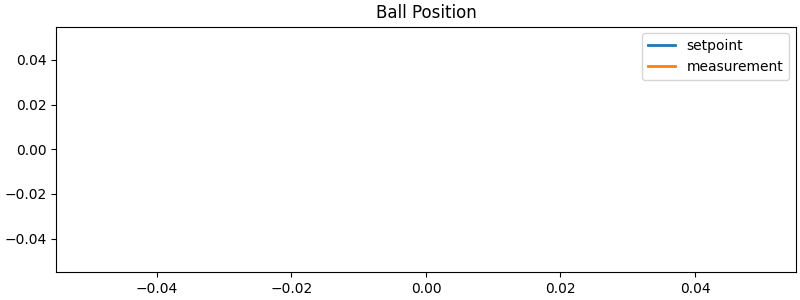

In [6]:
pid_plot = BallPlot()

Live plots of the servo's performance.

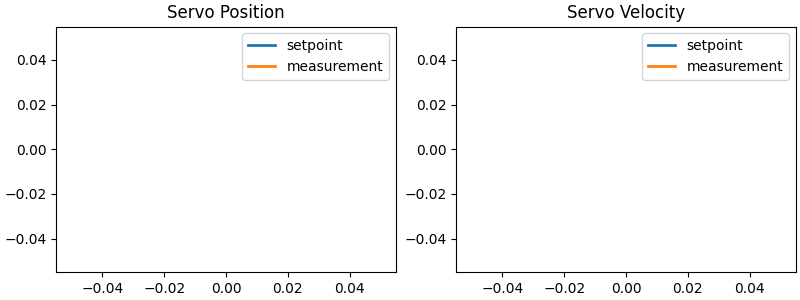

In [7]:
fig1, ax = plt.subplots(
    nrows=1, ncols=2,
    figsize=(8,3),
    gridspec_kw={'width_ratios':[1,1]}
)
fig1.set_constrained_layout(True)   # allow dynamic spacing

ax[0].set_title('Servo Position')
theta_beam_setpoint_x, theta_beam_setpoint_y = [], []
theta_beam_actual_x, theta_beam_actual_y = [], []
(theta_beam_setpoint_line,) = ax[0].plot([], [], lw=2, label='setpoint')
(theta_beam_actual_line,) = ax[0].plot([], [], lw=2, label='measurement')
ax[0].legend()
ax[1].set_title('Servo Velocity')
omega_beam_setpoint_x, omega_beam_setpoint_y = [], []
omega_beam_actual_x, omega_beam_actual_y = [], []
(omega_beam_setpoint_line,) = ax[1].plot([], [], lw=2, label='setpoint')
(omega_beam_actual_line,) = ax[1].plot([], [], lw=2, label='measurement')
ax[1].legend()

def update_servo_plot(t, new_theta_beam_setpoint, new_theta_beam_actual, new_omega_beam_setpoint, new_omega_beam_actual):
    # pos
    theta_beam_setpoint_x.append(t)
    theta_beam_setpoint_y.append(new_theta_beam_setpoint)
    theta_beam_actual_x.append(t)
    theta_beam_actual_y.append(new_theta_beam_actual)
    # vel
    omega_beam_setpoint_x.append(t)
    omega_beam_setpoint_y.append(new_omega_beam_setpoint)
    omega_beam_actual_x.append(t)
    omega_beam_actual_y.append(new_omega_beam_actual)
    if LIVE:
        show_servo_plot(t)
def show_servo_plot(t):
    # pos
    theta_beam_setpoint_line.set_data(theta_beam_setpoint_x, theta_beam_setpoint_y)
    theta_beam_actual_line.set_data(theta_beam_actual_x, theta_beam_actual_y)
    ax[0].set_xlim(0, t)
    ax[0].set_ylim(jnp.min(jnp.array(theta_beam_actual_y + theta_beam_setpoint_y)), jnp.max(jnp.array(theta_beam_actual_y + theta_beam_setpoint_y)))
    # vel
    omega_beam_setpoint_line.set_data(omega_beam_setpoint_x, omega_beam_setpoint_y)
    omega_beam_actual_line.set_data(omega_beam_actual_x, omega_beam_actual_y)
    ax[1].set_xlim(0, t)
    ax[1].set_ylim(jnp.min(jnp.array(omega_beam_actual_y + omega_beam_setpoint_y)), jnp.max(jnp.array(omega_beam_actual_y + omega_beam_setpoint_y)))
    fig1.canvas.draw()
    fig1.canvas.flush_events()

## Animation

Using RK4 for integration to propagate.

In [8]:
# simulation settings
if LIVE:
    viewer = Viewer1D(R, l_beam, q_init)
    viewer.jupyter_cell()
x0 = jnp.array(q_init + qdot_init)
for k in range(N):
    q, qdot = jnp.split(x0, 2)
    theta_beam_setpoint = controller.calculate(-q[0], dt)
    # servo controller(internal to the servo)
    servo_pos_controller.setpoint = theta_beam_setpoint
    omega_beam_setpoint = servo_pos_controller.calculate(q[3], dt)
    servo_vel_controller.setpoint = omega_beam_setpoint
    u = servo_vel_controller.calculate(qdot[3], dt)
    x0 = rk4_step(dyn_step, x0, dt, u)
    update_servo_plot(k*dt, theta_beam_setpoint, q[3], omega_beam_setpoint, qdot[3])
    pid_plot.update_ball_plot(k*dt, 0, q[0])
    if LIVE:
        viewer.render(q)
        time.sleep(dt)
if not LIVE:
    show_servo_plot(N * dt)
    pid_plot.show_ball_plot(N * dt)

## State-Space Control

Using the small angle approximation $sin(\alpha)\approx\alpha$

$\dot x=\left[\begin{pmatrix}v\\\dot\theta_{ball}\\ v_{beam}\\\dot\theta_{beam}\end{pmatrix}, \begin{pmatrix}-\frac{5g \theta_{beam}}{7}  \\ -\frac{5g \theta_{beam}}{7R} \\ 0 \\ u\end{pmatrix}\right]^T\implies x \in \mathbb{R}^8$

$y=\dot Ix \rightarrow$ System is fully observable. 

$u \in\mathbb{R}^8$

$\dot x = Ax + Bu = \begin{pmatrix}
0&0&0&0&1&0&0&0\\
0&0&0&0&0&1&0&0\\
0&0&0&0&0&0&1&0\\
0&0&0&0&0&0&0&1\\
0&0&0&-\frac{5}{7}g&0&0&0&0\\
0&0&0&-\frac{5g}{7R}&0&0&0&0\\
0&0&0&0&0&0&0&0\\
0&0&0&0&0&0&0&0\\
\end{pmatrix} x + 
\begin{pmatrix}
0&0\\
0& \ddots\\
&&\ddots\\
&&&\ddots\\
&&&&\ddots\\
&&&&&\ddots\\
&&&&&&0&0\\
&&&&&&0&1\end{pmatrix} u$

In [9]:
A = jnp.array([
    [0., 0., 0., 0., 1., 0., 0., 0.],
    [0., 0., 0., 0., 0., 1., 0., 0.],
    [0., 0., 0., 0., 0., 0., 1., 0.],
    [0., 0., 0., 0., 0., 0., 0., 1.],
    [0., 0., 0., -5 / 7 * g, 0., 0., 0., 0.],
    [0., 0., 0., -5 / 7 * g / R, 0., 0., 0., 0.],
    [0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 0., 0., 0., 0., 0., 0.],
])
B = jnp.array([
    [0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 0., 0., 0., 0., 0., 1.],
])
Q_lqr = jnp.array([
    [1., 0., 0., 0., 0., 0., 0., 0.],
    [0., 1., 0., 0., 0., 0., 0., 0.],
    [0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 0., 1., 0., 0., 0., 0.],
    [0., 0., 0., 0., 1., 0., 0., 0.],
    [0., 0., 0., 0., 0., 1., 0., 0.],
    [0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 0., 0., 0., 0., 0., 1.],
])
R_lqr = jnp.array([
    [1., 0., 0., 0., 0., 0., 0., 0.],
    [0., 1., 0., 0., 0., 0., 0., 0.],
    [0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 0., 1., 0., 0., 0., 0.],
    [0., 0., 0., 0., 1., 0., 0., 0.],
    [0., 0., 0., 0., 0., 1., 0., 0.],
    [0., 0., 0., 0., 0., 0., 1., 0.],
    [0., 0., 0., 0., 0., 0., 0., 1.],
])

### Controlability of 8-state system

$C=[B, AB, A^2B, \dots , A^{n-1}B]$, where $A \in M_{n\times n}$ and $B \in M_{n\times m}$

System is controllable if $rank(C)=n$. Since that is not the case for the 8-state system, the state needs to be reduced to include only controllable states(or states that are affected by the controllable states).

In [10]:
print(f"A shape: {A.shape}")
print(f"B shape: {B.shape}")
controllable, rank_C = check_controllability(A, B)
print(f"rank(C): {rank_C}")
print(f"Controllable: {controllable}")

A shape: (8, 8)
B shape: (8, 8)
rank(C): 4
Controllable: False


### State Reduction

The actuator commands beam angular acceleration, so the physically controllable dynamics are captured by the reduced state

$x_r = [r,\ \theta_{beam},\ \dot r,\ \dot\theta_{beam}]^T \in \mathbb{R}^4.$

The input is reduced to a scalar because there is only one actuator torque/command:
$u \in \mathbb{R}$.

So the reduced model is
$\dot x_r = A_r x_r + B_r u$,
with $A_r \in \mathbb{R}^{4\times 4},\quad B_r \in \mathbb{R}^{4\times 1},\quad Q_r \in \mathbb{R}^{4\times 4},\quad R_r \in \mathbb{R}^{1\times 1}.$

$A_r = \begin{pmatrix}0&0&1&0\\0&0&0&1\\0&-\frac{5}{7}g&0&0\\0&0&0&0\end{pmatrix}, B_r=\begin{pmatrix}0\\0\\0\\1\end{pmatrix}$

Then LQR gives a scalar-input feedback law $u = -K_r x_r$,

In [11]:
A = jnp.array([
    [0., 0., 1., 0.],
    [0., 0., 0., 1.],
    [0., -5.0 / 7.0 * g, 0., 0.],
    [0., 0., 0., 0.],
])

B = jnp.array([
    [0.],
    [0.],
    [0.],
    [1.],
])

# LQR weights for reduced model
Q_lqr = jnp.diag(jnp.array([1200.0, 320.0, 480.0, 260.0]))
R_lqr = jnp.array([[0.01]])

print(f"A shape: {A.shape}")
print(f"B shape: {B.shape}")
print(f"Q_lqr shape: {Q_lqr.shape}")
print(f"R_lqr shape: {R_lqr.shape}")

A shape: (4, 4)
B shape: (4, 1)
Q_lqr shape: (4, 4)
R_lqr shape: (1, 1)


In [12]:
controllable, rank_C = check_controllability(A, B)
print(f"rank(C): {rank_C}")
print(f"Controllable: {controllable}")

rank(C): 4
Controllable: True


K = [[-346.41016151  954.16844343 -377.28227749  167.05788484]]
S = [[1306.94414682 -578.70548869  471.70958455   -3.46410162]
 [-578.70548869 1567.57691123 -626.81569103    9.54168443]
 [ 471.70958455 -626.81569103  431.16046117   -3.77282277]
 [  -3.46410162    9.54168443   -3.77282277    1.67057885]]


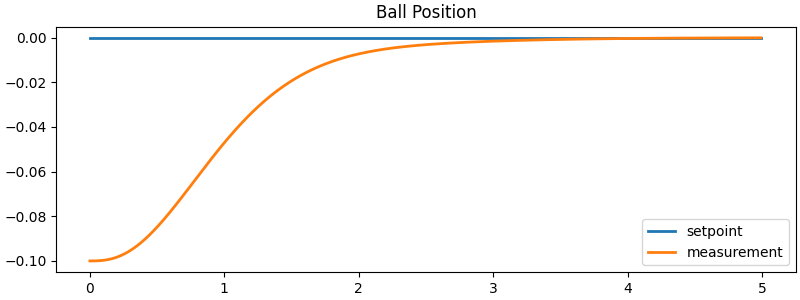

In [13]:
lqr_plot = BallPlot()
(K, S) = LinearQuadraticRegulator(A, B, Q_lqr, R_lqr)
print(f'K = {K}')
print(f'S = {S}')
def reduce_dimensions(x):
    return jnp.array([x[0], x[3], x[4], x[7]]) # [r, theta_beam, r_dot, theta_beam_dot]
# simulation settings
if LIVE:
    viewer = Viewer1D(R, l_beam, q_init)
    viewer.jupyter_cell()
x0 = jnp.array(q_init + qdot_init)
for k in range(N):
    u = -K @ reduce_dimensions(x0)
    x0 = rk4_step(dyn_step, x0, dt, u[-1])
    lqr_plot.update_ball_plot(k*dt, 0, x0[0])
    if LIVE:
        viewer.render(q)
        time.sleep(dt)
if not LIVE:
    lqr_plot.show_ball_plot(N * dt)

## Feedforward Neural Network

The input is the reduced state from the LQR approach except $r$ becomes $\Delta r=r-r_{\mathrm{setpoint}}$, but for now assume $r_{\mathrm{setpoint}}=0$, so: 

$x_r = [r,\ \theta_{beam},\ \dot r,\ \dot\theta_{beam}]^T \in \mathbb{R}^4.$ and the output is $u$.

In [17]:
class FFNetwork(nnx.Module):
    def __init__(self, input_size: int, hidden_size: int, output_size: int, rngs: nnx.Rngs):
        self.fc1 = nnx.Linear(input_size, hidden_size, rngs=rngs)
        self.fc2 = nnx.Linear(hidden_size, hidden_size, rngs=rngs)
        self.fc3 = nnx.Linear(hidden_size, output_size, rngs=rngs)
    
    def __call__(self, x):
        x = nnx.relu(self.fc1(x))
        x = nnx.relu(self.fc2(x))
        return self.fc3(x)

In [25]:
# Initialize network
ff_network = FFNetwork(input_size=4, hidden_size=128, output_size=1, rngs=nnx.Rngs(0))

# Create optimizer
optimizer = nnx.ModelAndOptimizer(ff_network, optax.adam(learning_rate=1e-4))

# for symmetrical evaluation
q_init = [0.1, 0., 0., 0.] # ball pos[m], ball angle[rad], beam pos[m], beam angle[rad]
q_opp_init = [-0.05, 0., 0., 0.] # ball pos[m], ball angle[rad], beam pos[m], beam angle[rad]
qdot_init = [0., 0., 0., 0.] # ball vel[m/s], ball angular vel[rad/s], beam vel[m/s], beam angular vel[rad/s]

def loss_fn(model):
    # x = jnp.array(q_init + qdot_init)
    # total_loss = 0.0
    # for _ in range(N//2):
    #     action = model(reduce_dimensions(x))
    #     x = rk4_step(dyn_step, x, dt, action[0])
    #     total_loss += x[0] ** 2
    # return total_loss
    def simulate(x):
        total_loss = 0.0
        for _ in range(N // 2):
            action = model(reduce_dimensions(x))
            x = rk4_step(dyn_step, x, dt, action[0])
            total_loss += x[0] ** 2
        return total_loss
    return simulate(jnp.array(q_init + qdot_init)) + simulate(jnp.array(q_opp_init + qdot_init))

# Training loop
num_epochs = 1000
for epoch in tqdm(range(num_epochs), desc="Training"):
    loss, grads = nnx.value_and_grad(loss_fn)(ff_network)
    optimizer.update(grads)
    tqdm.write(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss:.4f}')

Training:   0%|          | 0/1000 [00:00<?, ?it/s]

Training:   0%|          | 1/1000 [00:16<4:29:52, 16.21s/it]

Epoch [1/1000], Loss: 4.5403


Training:   0%|          | 2/1000 [00:32<4:31:27, 16.32s/it]

Epoch [2/1000], Loss: 3.9831


...

Epoch [998/1000], Loss: 0.9287


Training: 100%|█████████▉| 999/1000 [4:56:56<00:17, 17.87s/it]

Epoch [999/1000], Loss: 0.9279


Training: 100%|██████████| 1000/1000 [4:57:14<00:00, 17.83s/it]

Epoch [1000/1000], Loss: 0.9270


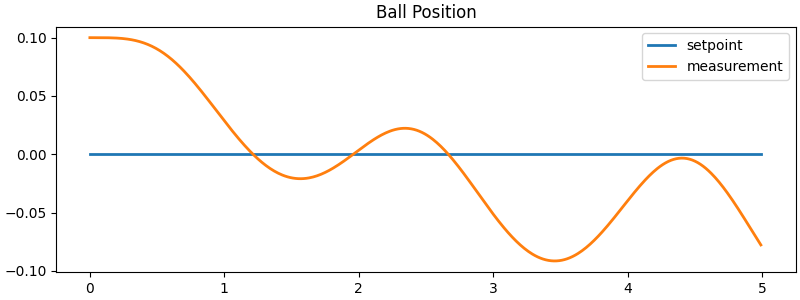

In [26]:
# Run the simulation with the trained network
nn_plot = BallPlot()
x0 = jnp.array(q_init + qdot_init)
for k in range(N):
    action = ff_network(reduce_dimensions(x0))
    x0 = rk4_step(dyn_step, x0, dt, action[0])
    nn_plot.update_ball_plot(k*dt, 0, x0[0])

nn_plot.show_ball_plot(N * dt)